# Naive Bayes
Dataset - [SMS Spam Collection](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset)

# 📌 Наивті Байес (Naive Bayes) алгоритмі: Толық теориялық шпаргалка

Наивті Байес — бұл Томас Байестің ықтималдық теоремасына негізделген, деректерді топтарға (кластарға) бөлуге арналған машиналық оқыту алгоритмі. Ол әсіресе мәтіндерді талдау (NLP), спамды сүзгілеу және көңіл-күйді (sentiment) анықтауда өте танымал.

---

## 1. Негізгі ұғым: Байес теоремасы қалай жұмыс істейді?

Байес теоремасы бізге белгілі бір оқиғаның алдын ала (априорлық) ықтималдығын жаңа деректер негізінде жаңартуға (апостериорлық ықтималдық) мүмкіндік береді.

**Формуласы:**
P(A|B) = [ P(B|A) * P(A) ] / P(B)

**Спамды анықтау мысалында бұл нені білдіреді?**
* **A оқиғасы:** Хаттың СПАМ болуы.
* **B оқиғасы:** Хаттың ішінде "ұттыңыз", "миллион" деген сияқты нақты сөздердің болуы.
* **P(A|B) (Апостериорлы ықтималдық):** Хаттың ішінде осы сөздер болған жағдайда, оның спам болу ықтималдығы. Біз осыны іздейміз.
* **P(B|A) (Шындыққа жанасымдылық / Likelihood):** Хат спам екені нақты белгілі болса, онда осы сөздердің кездесу ықтималдығы.
* **P(A) (Априорлы ықтималдық / Prior):** Біздің базамыздағы жалпы хаттардың ішінде спам хаттардың үлесі қандай?
* **P(B) (Дәлел / Evidence):** Жалпы барлық хаттарда (спам және таза хаттарды қосқанда) осы сөздердің кездесу ықтималдығы.

---
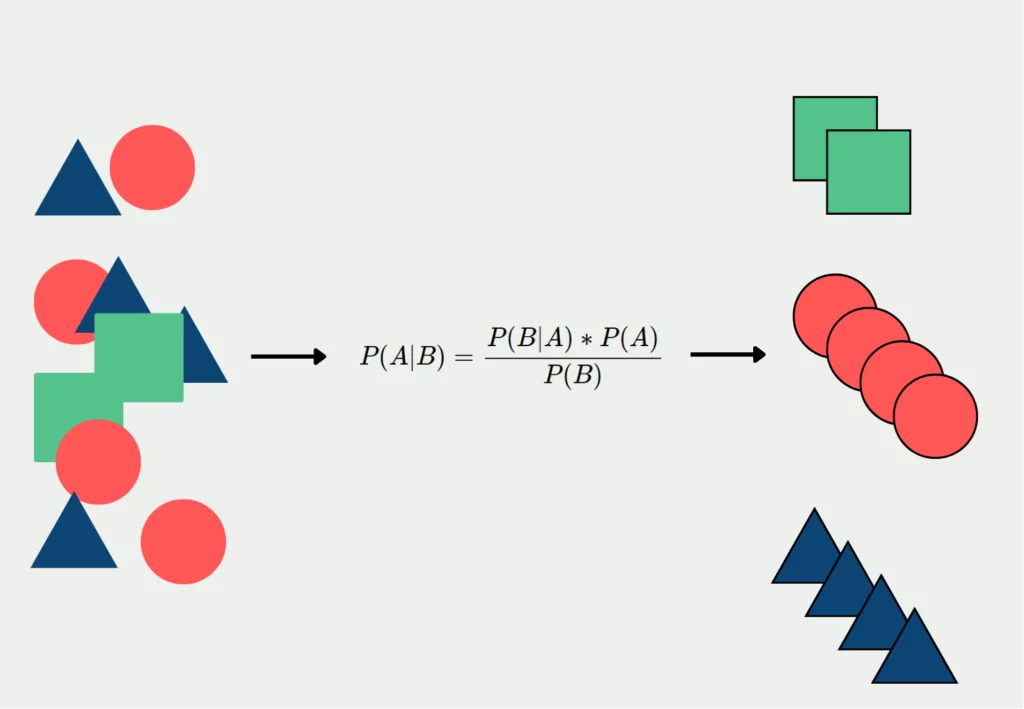
---

## 2. Неге алгоритм "Наивті" (Аңқау) деп аталады?

Алгоритм өте үлкен және батыл болжам жасайды: **Ол мәтіндегі әрбір белгіні (сөзді) бір-біріне мүлдем тәуелсіз деп санайды.**

Мәтінде грамматика, сөздердің орналасу реті және контекст бар. Мысалы, "Мен сені жақсы көремін" деген сөйлемдегі сөздер бір-бірімен тығыз байланысты. Бірақ Наивті Байес бұл байланысты "көрмейді". Ол "мен", "сені", "жақсы", "көремін" сөздерін бір-біріне еш қатысы жоқ, кездейсоқ шашылған элементтер ретінде жеке-жеке бағалайды. Осы қасиеті үшін ол "аңқау" немесе "наивті" деп аталады.

Бұл кемшілік сияқты көрінгенімен, дәл осы "аңқаулық" алгоритмге өте күрделі есептеулерден қашып, өте үлкен жылдамдықпен жұмыс істеуге мүмкіндік береді.

---

## 3. Маңызды теория: "Нөлдік жиілік" мәселесі және Лаплас тегістеуі (Laplace Smoothing)

**Мәселе (Zero Frequency):** Егер сіз модельді жаттықтырған кезде базада "лотерея" деген сөз мүлдем кездеспесе, алгоритм оның ықтималдығын 0 деп белгілейді. Формулада көбейту амалы қолданылатындықтан, хаттың ішінде басқа 10 спам сөз болса да, бір ғана жаңа сөз ("лотерея") бүкіл көбейтіндіні 0-ге теңестіріп жібереді.

**Шешімі (Laplace Smoothing):** Бұл мәселені шешу үшін әрбір сөздің кездесу санына автоматты түрде +1 қосылады. Бұл жаңа немесе сирек кездесетін сөздердің ықтималдығын нөлге түсірмей, модельдің қатесіз жұмыс істеуін қамтамасыз етеді. Scikit-learn кітапханасында бұл `alpha=1.0` параметрі арқылы автоматты түрде іске қосылған.

---

## 4. Наивті Байес түрлері (Модельді қалай таңдаймыз?)

1. **Multinomial Naive Bayes:** Сөздердің кездесу жиілігіне (санына) негізделген. Егер "ақша" сөзі 5 рет кездессе, бұл есепке алынады. NLP және мәтін талдау үшін ең танымал таңдау.
2. **Bernoulli Naive Bayes:** Тек екілік (0 немесе 1) жүйеде жұмыс істейді. Ол сөздің неше рет кездескеніне қарамайды, тек "сөз бар ма?" (1) немесе "сөз жоқ па?" (0) деген сұраққа жауап береді.
3. **Gaussian Naive Bayes:** Деректер үздіксіз (бөлшек сандар, температура, ұзындық) болғанда және қалыпты үлестірімге (bell curve) бағынғанда қолданылады.

---

## 5. Алгоритмнің Артықшылықтары мен Кемшіліктері

**Артықшылықтары:**
* Аз деректермен де сенімді жұмыс істейді.
* Оқыту және болжау уақыты өте аз (математикасы жеңіл болғандықтан).
* Көп класты жіктеу (multi-class classification) есептеріне жақсы бейімделген.
* Шулы немесе маңызды емес белгілерге аса сезімтал емес.

**Кемшіліктері:**
* Белгілердің (сөздердің) тәуелсіздігі туралы болжамы шынайы өмірде сирек кездеседі.
* Сөздердің семантикалық мағынасын және контексін түсінбейді (мысалы, "жаман емес" деген тіркесті "жаман" және "емес" деп бөліп тастайды).

---

## 6. Практика: Python + Scikit-Learn коды

Төмендегі код осы теорияны іске асырады.

```python
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix

# 1. Деректерді жүктеу (UCI Spam Dataset)
url = "[https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv](https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv)"
df = pd.read_csv(url, sep='\t', names=['label', 'message'])

# 2. Деректерді тазалау (Белгілерді сандарға ауыстыру)
# Наивті Байес математикалық модель болғандықтан, 'ham'/'spam' мәтінін 0 және 1-ге айналдырамыз
df['label_num'] = df.label.map({'ham': 0, 'spam': 1})

# 3. Деректерді X (белгілер) және y (нысана) етіп бөлу
X = df.message
y = df.label_num

# 4. Деректерді Жаттығу (80%) және Тест (20%) жиындарына бөлу
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Векторизация: Мәтінді Сандық Матрицаға айналдыру (Bag of Words моделі)
# Компьютер мәтінді түсінбегендіктен, сөздердің жиілігін санайтын матрица құрамыз
vectorizer = CountVectorizer()
X_train_matrix = vectorizer.fit_transform(X_train)
X_test_matrix = vectorizer.transform(X_test) # Тест деректерін тек transform жасаймыз (оқытпаймыз!)

# 6. Multinomial Naive Bayes моделін құру және оқыту
nb_model = MultinomialNB(alpha=1.0) # alpha=1.0 - бұл жоғарыда аталған Laplace Smoothing
nb_model.fit(X_train_matrix, y_train)

# 7. Модельді тексеру
y_pred = nb_model.predict(X_test_matrix)
print(f"Модель дәлдігі: {accuracy_score(y_test, y_pred) * 100:.2f}%")

# 8. Өзіміздің хаттарды тексеріп көру
my_emails = [
    "Congratulations! You've won a $1,000 Walmart gift card. Go to [http://bit.ly/1234](http://bit.ly/1234) to claim now.",
    "Hey, what time are we meeting tomorrow for the project presentation?"
]

my_emails_matrix = vectorizer.transform(my_emails)
predictions = nb_model.predict(my_emails_matrix)

print("\n--- Тексеру нәтижесі ---")
for email, prediction in zip(my_emails, predictions):
    status = "СПАМ 🚩" if prediction == 1 else "ТАЗА ХАТ 🟢"
    print(f"[{status}] : {email}")

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

In [12]:
data = pd.read_csv("/content/spam.csv", encoding="latin-1")
data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [13]:
data.shape

(5572, 5)

In [14]:
data = data.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1)
data

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [16]:
# Меткаларды (label) сандарға айналдыру
# Компьютер 'ham' / 'spam' сөздерін түсінбегендіктен, оларды 0 және 1-ге ауыстырамыз
data['v1_label'] = data['v1'].map({'ham': 0, 'spam': 1})
data['v1_label'].head()

,v1_label
0,0
1,0
2,1
3,0
4,0


In [19]:
X = data['v2']
y = data['v1_label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
X_train.head()

,v2
1978,No I'm in the same boat. Still here at my moms...
3989,(Bank of Granite issues Strong-Buy) EXPLOSIVE ...
3935,They r giving a second chance to rahul dengra.
4078,O i played smash bros &lt;#&gt; religiously.
4086,PRIVATE! Your 2003 Account Statement for 07973...


In [25]:
vectorizer = CountVectorizer()
X_train_matrix = vectorizer.fit_transform(X_train)
X_test_matrix = vectorizer.transform(X_test)

In [26]:
naive = MultinomialNB()
naive.fit(X_train_matrix, y_train)

MultinomialNB()

In [27]:
# Тест деректерінде тексеріп, дәлдігін есептеу
predictions = naive.predict(X_test_matrix)
accuracy = accuracy_score(y_test, predictions)

print(f"✅ Модельдің дәлдігі: {accuracy * 100:.2f}%\n")

# Толық есеп (Қателер қай жерде кеткенін көру үшін)
print("📊 Толық есеп (Classification Report):")
print(classification_report(y_test, predictions, target_names=['Ham (0)', 'Spam (1)']))

✅ Модельдің дәлдігі: 98.39%

📊 Толық есеп (Classification Report):
              precision    recall  f1-score   support

     Ham (0)       0.98      1.00      0.99       965
    Spam (1)       0.99      0.89      0.94       150

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



### 📊 Модельдің қорытынды нәтижелері (Results & Evaluation)

Наивті Байес моделі SMS Spam Collection деректер жиынтығында келесідей жоғары көрсеткіштерді көрсетті:

* **Жалпы дәлдік (Accuracy):** **98.39%** — модель 1115 тесттік хаттың басым көпшілігін қатесіз таныды.
* **Precision (Нақтылық - Spam):** **0.99 (99%)** — бұл модельдің ең басты артықшылығы. Егер модель хатты "Спам" деп белгілесе, ол 99% жағдайда қателеспейді. Бұл маңызды хаттардың байқаусызда спамға кетпеуін қамтамасыз етеді.
* **Recall (Қамту - Spam):** **0.89 (89%)** — модель барлық спам хаттардың 89%-ын ұстап қалды. Қалған 11%-ы "таза хат" ретінде өткенімен, бұл қауіпсіздік пен пайдаланушы ыңғайлылығы арасындағы жақсы баланс болып табылады.
* **F1-Score:** **0.94** — модельдің спамды анықтаудағы жалпы тиімділігінің жоғары екенін көрсететін теңгерімді көрсеткіш.



#### 🔍 Түйін (Insight):
Модель мәтіндік деректерді өңдеуде (NLP) Наивті Байес алгоритмінің өте жылдам әрі сенімді екенін дәлелдеді. Әсіресе **MultinomialNB** пен **CountVectorizer** комбинациясы спам-фильтрлеу есептері үшін ең оңтайлы шешімдердің бірі болып табылады.

In [29]:
import joblib

# 1. Модельді сақтау
joblib.dump(naive, 'spam_model.pkl')

# 2. Векторизаторды сақтау (міндетті түрде!)
joblib.dump(vectorizer, 'vectorizer.pkl')

print("Модель мен векторизатор сәтті сақталды!")

Модель мен векторизатор сәтті сақталды!
